In [1]:
# Imports
from astropy import units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord, FK5
from spectral_cube import SpectralCube
from sting import extract_streamline, gradient_descent, outputs
import os
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

# Settings
star_position = SkyCoord("3h28m55.569s", "+31d14m37.025s", frame='fk5')
star_ref = star_position.skyoffset_frame()
distance = 293 #parsecs
v_lsr = 7.5 #km/s
save_folder = "sting_results"
loss_method = 1 # 0: RADECVEL, 1: RTHETAVEL

# File
cubefile = 'data/example_streamer_cluster_data.fits'


/Users/laurenmason/.pyenv/versions/.stingenv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Prepare 1D streamer emission from cube

The cube should contain only streamer emission. See 'how do I isolate my streamer emission?' (to be written).

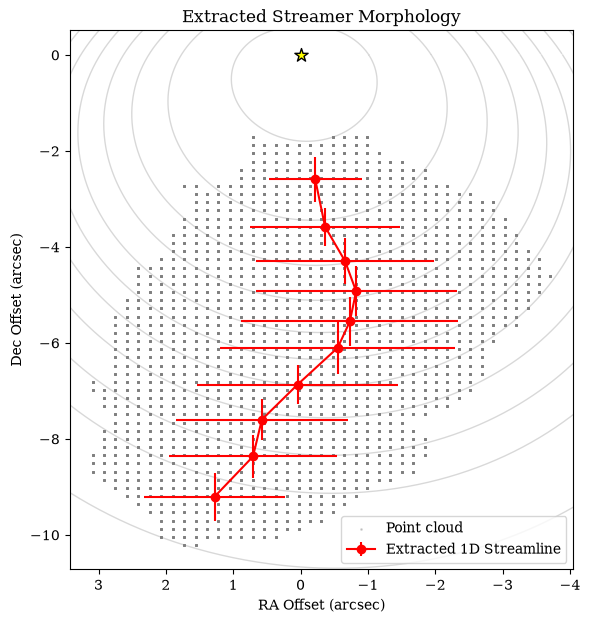

In [2]:
# Set:
n_points = 10 # the number of points we want to reduce the data to
# -----------------------------------------------------------------

# Optional: trim cube to smaller region that just contains the streamer.
# Set any of these to None to not apply that limit.
# ----------------------------------------------------------------
vmin = 6 * u.km/u.s             # e.g. 6 * u.km/u.s
vmax = 8 * u.km/u.s             # e.g. 8 * u.km/u.s  
xmin = -5 * u.arcsec            # e.g. -5 * u.arcsec
xmax = 5 * u.arcsec             # e.g. 5 * u.arcsec 
ymin = -12 * u.arcsec           # e.g. -12 * u.arcsec
ymax = 0.5 * u.arcsec           # e.g. 0.5 * u.arcsec
rms_thresh = 4
# ----------------------------------------------------------------


hdu = fits.open(cubefile)[0]
cube = SpectralCube.read(hdu).with_spectral_unit(u.km/u.s, rest_value=hdu.header['RESTFRQ']*u.Hz)
streamer_cube = extract_streamline.extract_streamer_subcube(cube, vmin=vmin, vmax=vmax, xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax, rms_thresh=rms_thresh)

streamer = extract_streamline.reduce_to_1D(streamer_cube, star_position, n_elements=n_points)

# extract metric boundaries for plotting later
partitions = extract_streamline.get_metric_partitions(streamer.pc_coords, n_elements=n_points)
metric_boundaries, _ = extract_streamline.sample_metric_boundaries(streamer.pc_coords, partitions)

# plot the extracted morphology
outputs.plot_morphology(
    streamer=streamer,
    show=True,
    save_folder=None,
    metric_boundaries=metric_boundaries,
    title="Extracted Streamer Morphology",
)


## 2. Initial Guess

First set your input params in the format required (separate params to optimise and params to stay fixed). Use units.

In [3]:
# Parameters to optimize
initial_opt_params = {
    'r0': 1000.0 * u.au,  # au
    'theta0': 10.0 * u.deg,  # degrees
    'phi0': 140.0 * u.deg,  # degrees
    # 'rc': 0.1*1500,  # au
    'omega': 4e-13,  # 1/s
    'v_r0': 0.3 * u.km / u.s, # km/s
    'inc': -30.0 * u.deg,  # degrees
    'pa': 120.0 * u.deg,  # degrees
    'mass': 3.2 * u.Msun,  # solar masses
}

fixed_params = {
    'rmin': 50.0 * u.au,  # au
    'deltar': 30.0 * u.au,  # au
    'v_lsr': 7.5 * u.km / u.s,  # km/s (systemic velocity)
}

# prepare the params for sting
model_params, initial_opt_params, fixed_params = gradient_descent.prepare_model_params(initial_opt_params, fixed_params)

Now we run the forward model for the initial guess, and calculate the loss (i.e. the 'difference' between the model and data streamline)

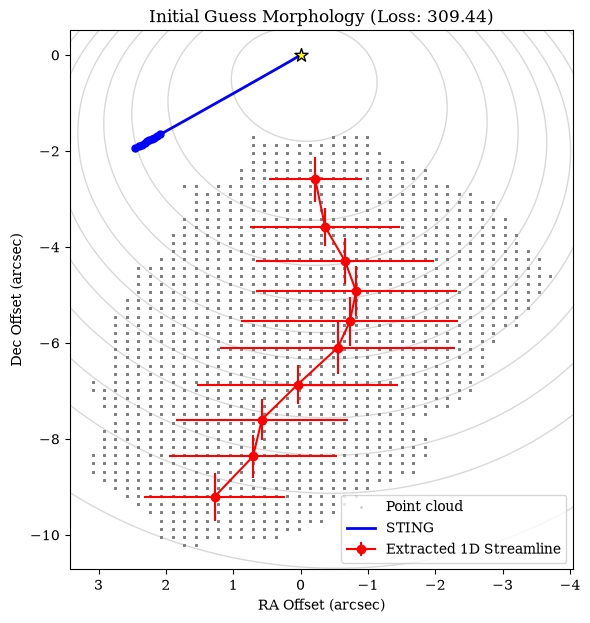

In [4]:
# Run forward model and compute loss for the initial guess
initial_guess = gradient_descent.evaluate_initial_guess(initial_opt_params, fixed_params, streamer.data, streamer.uncertainties, distance, n_elements=n_points, loss_method=loss_method,)

# Morphology plot of the initial guess
partitions = extract_streamline.get_metric_partitions(streamer.pc_coords, n_elements=n_points)
metric_boundaries, _ = extract_streamline.sample_metric_boundaries(streamer.pc_coords, partitions)

outputs.plot_morphology(
    streamer=streamer,
    ra_model=initial_guess.ra_model,
    dec_model=initial_guess.dec_model,
    ra_model_interp=initial_guess.ra_model_interp,
    dec_model_interp=initial_guess.dec_model_interp,
    valid=initial_guess.valid,
    metric_boundaries=metric_boundaries,
    save_folder=save_folder,
    save_name='initial_guess_morphology',
    show=True,
    title=f"Initial Guess Morphology (Loss: {initial_guess.chi2_total:.2f})",
)

Now go back and adjust your initial guess parameters if the initial guess looks really bad.

The initial guess does not need to be especially good, so do not spend long on this step. The most important thing is that the initial model is approximately as long as the data streamline on the sky plane.

Once happy with your initial guess, continue.

## 3. Set bounds and priors.

If you wish to optimise `r0` or `mass`, you must provide bounds for them here.

To reduce degeneracy, it is recommended to add priors for any of `[mass, inc, pa]`, if you wish to optimise any of the pairs `[mass, omega / rc]`, `[inc, theta0]`, `[pa, phi0]`.

In [5]:
param_bounds = {
    'r0': (200.0, 10000.0) * u.au,                    # radius between 200-20000 au
    'mass': (3, 10) * u.Msun,                    # mass between 3.0 and 10.0 solar masses
}

param_priors = {
    'mass': (4.0, 1.0) * u.Msun,  # Gaussian prior on mass with mean 4.0 Msun and stddev 1.0 Msun
    'inc': (-45.0, 10.0) * u.deg,  # Gaussian prior on inclination with mean -45 deg and stddev 10 deg
    'pa': (194.0, 10.0) * u.deg,  # Gaussian prior on position angle with mean 194 deg and stddev 10 deg
}

## 4. Fit streamline

Choose your settings, or leave them as the defaults, and run STING.

Starting optimisation with 2000 epochs...
Loss method: 1
optimising parameters: ['r0', 'theta0', 'phi0', 'v_r0', 'inc', 'pa', 'mass', 'mu']
Fixed parameters: ['rmin', 'deltar', 'v_lsr']
Priors:
  mass: mean=4 M_sun, sigma=1 M_sun
  inc: mean=-45 deg, sigma=10 deg
  pa: mean=194 deg, sigma=10 deg
Threshold-based stopping enabled: loss <= 0.05 for 20 consecutive epochs.
Gradient norm stopping enabled (normalised space): ||grad|| < 0.08 for 20 consecutive epochs.
Initial optimisable values:
  r0: 1000 au
  theta0: 10 deg
  phi0: 140 deg
  v_r0: 0.3 km/s
  inc: -30 deg
  pa: 120 deg
  mass: 3.2 M_sun
  mu: 0.00126134
Initial loss: 367.095

 Starting Epoch 50 -------------------------
Epoch 50/2000, Loss: 13.048439, Best Loss: 13.048439, ||grad||: 2.006080e+02

 Starting Epoch 100 -------------------------
Epoch 100/2000, Loss: 3.613830, Best Loss: 3.613830, ||grad||: 4.232374e+01

 Starting Epoch 150 -------------------------
Epoch 150/2000, Loss: 1.888908, Best Loss: 1.888908, ||grad||: 2

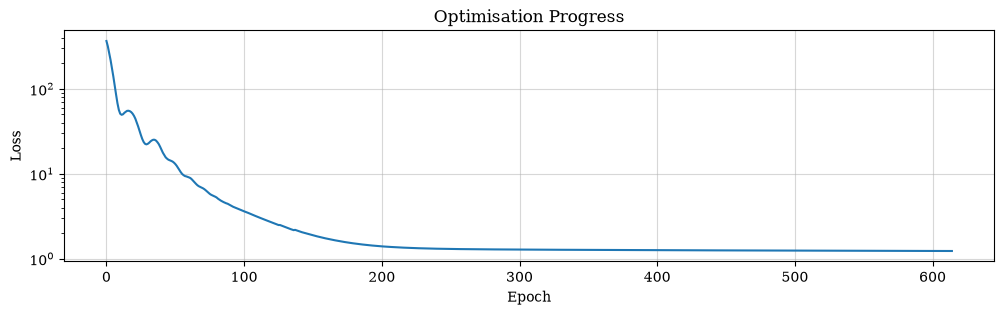

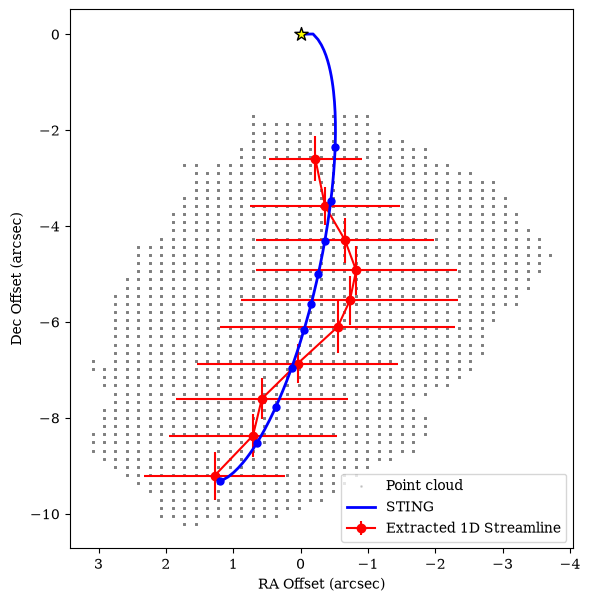

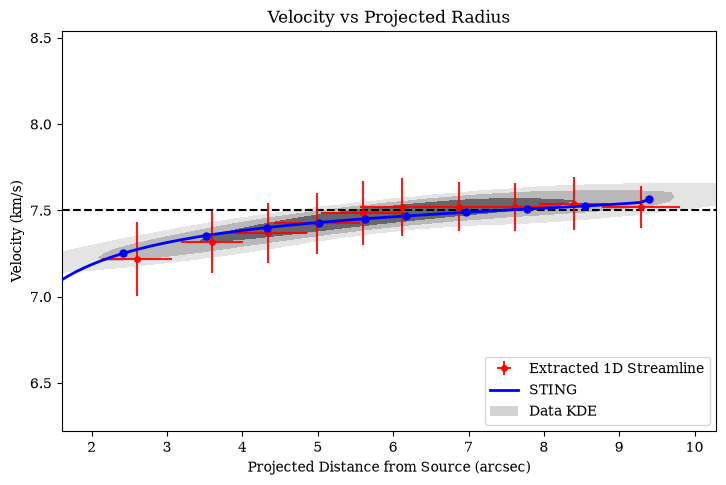

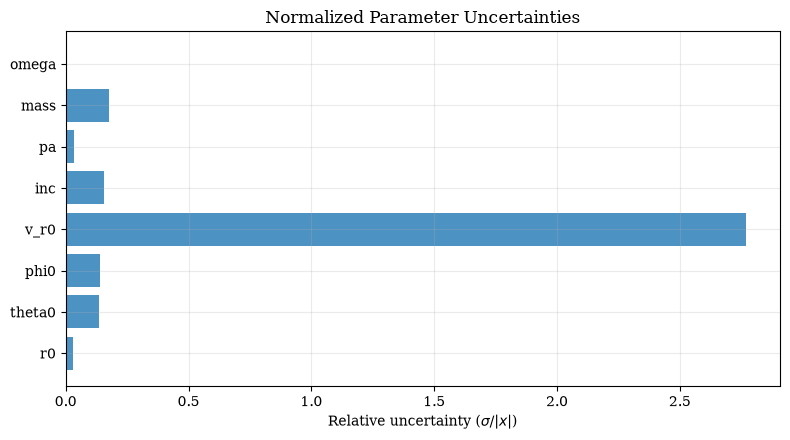

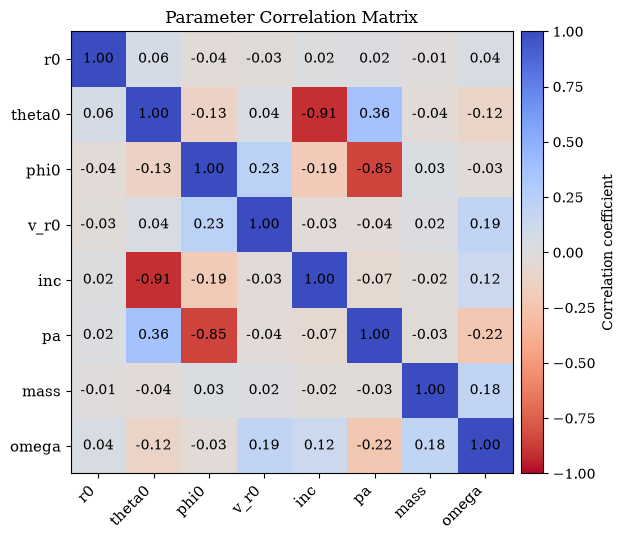

Optimized using loss_method='1'


In [6]:

n_epochs = 2000
info_every = 50 # Prints optimization info every n epochs
learning_rate = 0.01 # Single learning rate applied to all normalized optimization parameters.
# Higher learning rates can lead to faster convergence, but may also cause instability. Adjust as needed
gradient_tol = 1e-2 * len(initial_opt_params) # gradient tolerance scaled by number of parameters

result = gradient_descent.fit_streamline(
    initial_opt_params,
    fixed_params,
    streamer,
    distance,
    learning_rate=learning_rate,
    param_bounds=param_bounds,
    n_epochs=n_epochs,
    info_every=info_every,
    loss_threshold=0.05,
    loss_threshold_epochs=20,
    gradient_tol=gradient_tol,
    gradient_tol_epochs=20,
    early_stopping_patience=210,
    loss_method=loss_method,
    priors=param_priors,
    save_folder=save_folder,
    v_lsr=v_lsr,
    show_plots=True,
 )

print(f"Optimized using loss_method='{loss_method}'")


## 5. Optional plots

Some other plots which you might wish to make

### Best fit, overlaid with by-eye fit

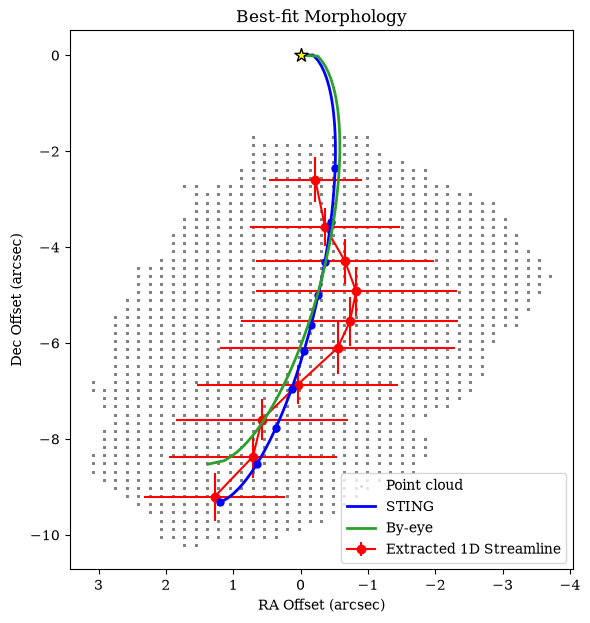

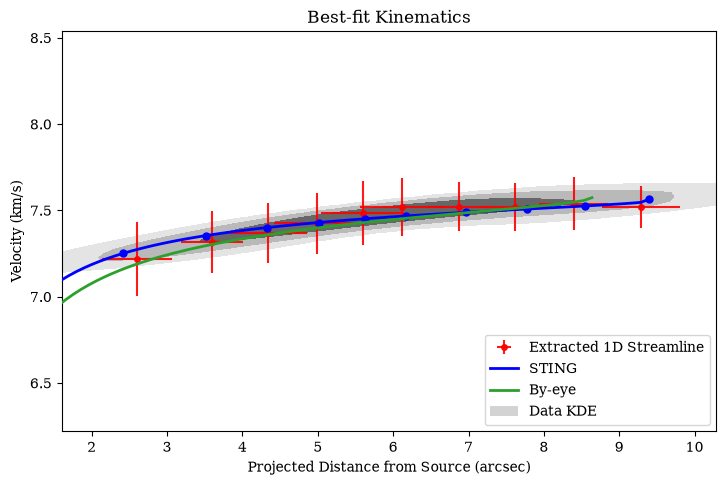

In [7]:
by_eye_params = {
    'r0': 2540.0 * u.au,
    'theta0': 54.0 * u.deg,
    'phi0': 61.0 * u.deg,
    'omega': 7e-13 * (1/u.s),
    'v_r0': 0.001 * u.km / u.s,
    'mass': 4.0 * u.Msun,
    'inc': -45.0 * u.deg,
    'pa': 194.0 * u.deg,
}

best_fit = outputs.evaluate_best_fit(
    result.best_opt_params, fixed_params, streamer.data, distance,
    by_eye_params=by_eye_params,
)

outputs.plot_morphology(
    streamer=streamer,
    ra_model=best_fit['ra_model'],
    dec_model=best_fit['dec_model'],
    ra_model_interp=best_fit['ra_model_interp'],
    dec_model_interp=best_fit['dec_model_interp'],
    valid=best_fit['valid'],
    by_eye=best_fit['by_eye'],
    save_folder=save_folder,
    save_name='best_fit_morphology',
    title="Best-fit Morphology",
    show=True,
)

outputs.plot_vel_radius(
    ra_model=best_fit['ra_model'],
    dec_model=best_fit['dec_model'],
    v_model=best_fit['v_model'],
    streamer=streamer,
    ra_model_interp=best_fit['ra_model_interp'],
    dec_model_interp=best_fit['dec_model_interp'],
    v_model_interp=best_fit['v_model_interp'],
    valid=best_fit['valid'],
    by_eye=best_fit['by_eye'],
    save_folder=save_folder,
    save_name='best_fit_vel_radius',
    title="Best-fit Kinematics",
    show=True,
)

### Streamline spaghetti
i.e. sample covariance matrix for best-fit parameters and plot `n_samples` possible streamlines

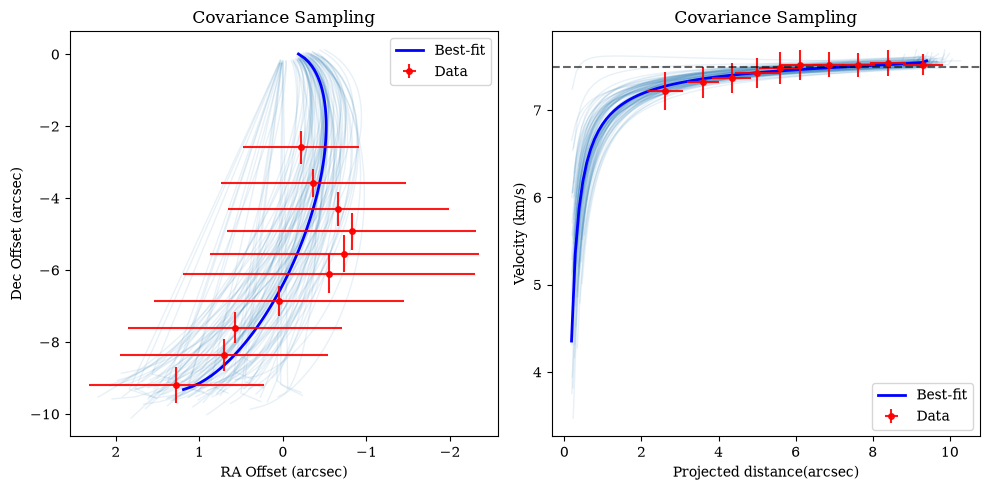

In [8]:
n_samples = 100
outputs.plot_streamline_covariance_samples(
    best_opt_params=result.best_opt_params,
    fixed_params=fixed_params,
    data=streamer.data,
    uncertainties=streamer.uncertainties,
    distance=distance,
    covariance_result=result.covariance_result,
    v_lsr=v_lsr,
    n_samples=100,
    save_folder=save_folder,
)

### Parameter evolution

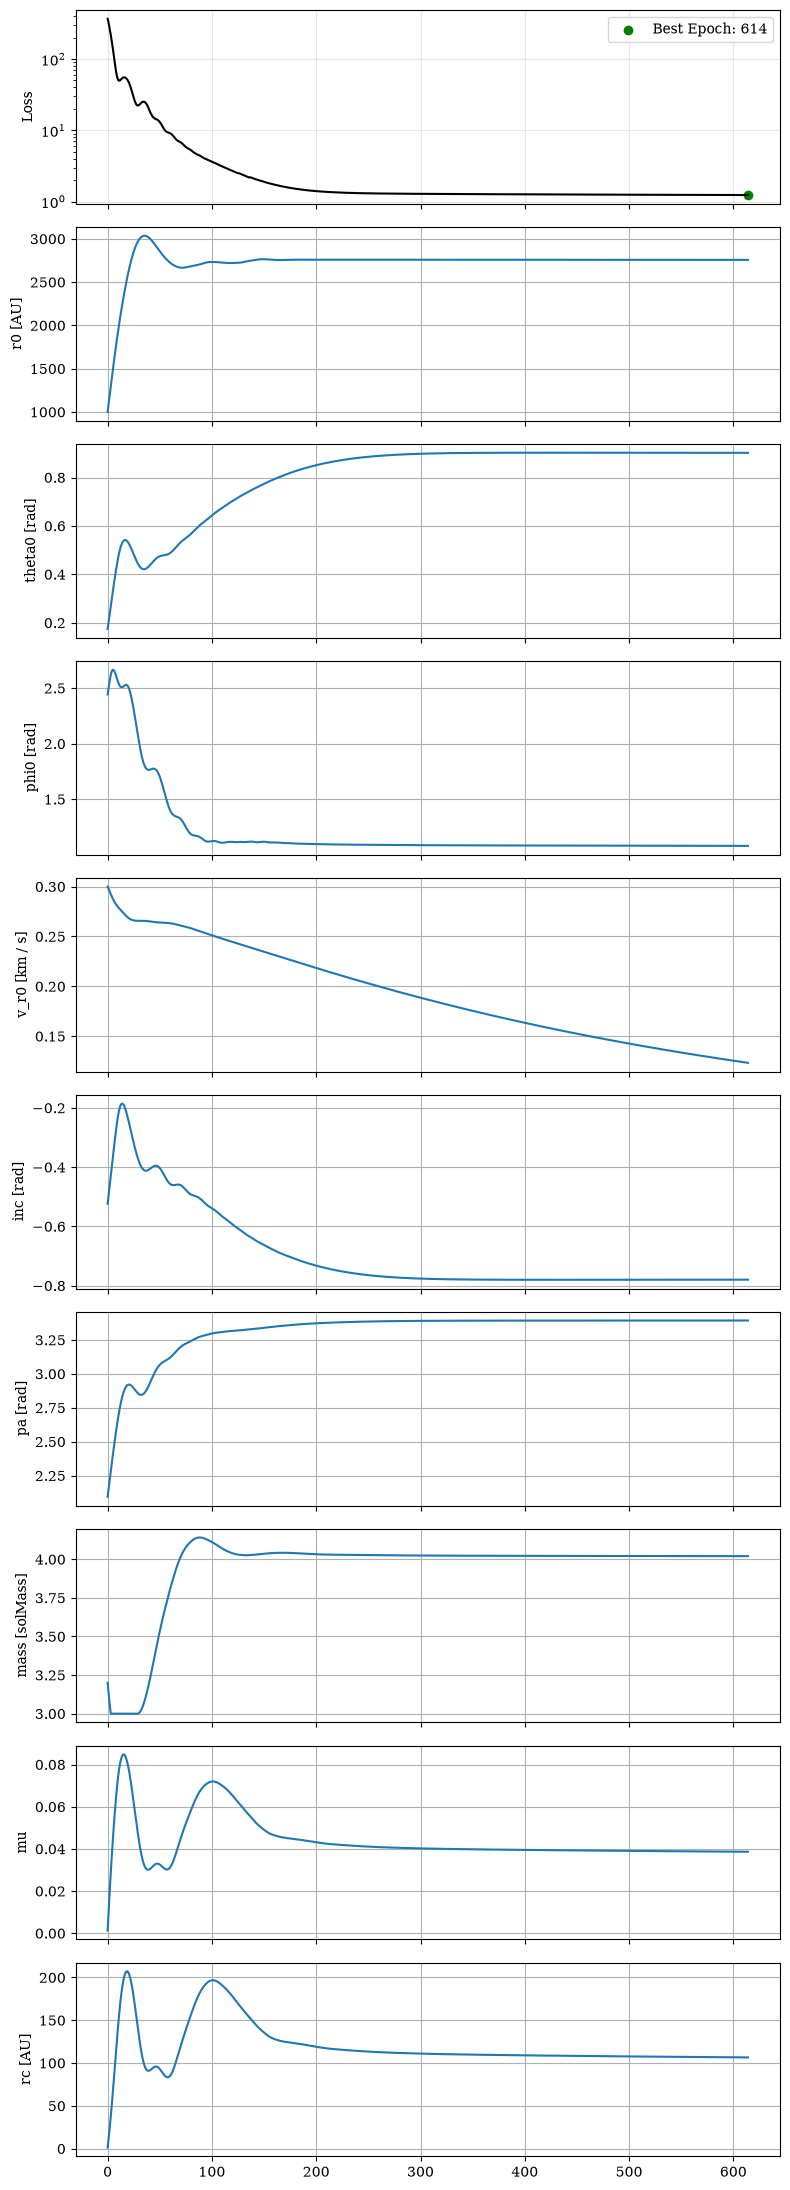

In [9]:
outputs.plot_param_optimisation_history(save_folder=save_folder)

### Plots at every epoch

RA - Dec, RA - Velocity, Dec - Velocity, and Velocity - Projected Radius

Note: time increases ~linearly with number of epochs

Set make_video=True to also string each set of these plots into a video

In [10]:
outputs.plot_morphology_by_epoch(
    gradient_descent=gradient_descent,
    fixed_params=fixed_params,
    initial_opt_params=initial_opt_params,
    distance=distance,
    streamer=streamer,
    n_points=n_points,
    save_folder=save_folder,
    make_video=True
)

Video saved to sting_results/epochs/morphology/streamline_morphology_evolution.mp4


In [11]:
outputs.plot_ra_vel_by_epoch(
    gradient_descent=gradient_descent,
    fixed_params=fixed_params,
    initial_opt_params=initial_opt_params,
    distance=distance,
    streamer=streamer,
    save_folder=save_folder,
    make_video=True
)

Video saved to sting_results/epochs/ra_vel/streamline_ra_vel_evolution.mp4


In [12]:
outputs.plot_dec_vel_by_epoch(
    gradient_descent=gradient_descent,
    fixed_params=fixed_params,
    initial_opt_params=initial_opt_params,
    distance=distance,
    streamer=streamer,
    save_folder=save_folder,
    make_video=True
)

Video saved to sting_results/epochs/dec_vel/streamline_dec_vel_evolution.mp4


In [13]:


# now doing plots of velocity vs projected radius by epoch, with a KDE background
outputs.plot_vel_radius_by_epoch(
    gradient_descent=gradient_descent,
    fixed_params=fixed_params,
    initial_opt_params=initial_opt_params,
    distance=distance,
    streamer=streamer,
    velocity_reference=v_lsr,
    save_folder=save_folder,
    make_video=True
)

Video saved to sting_results/epochs/vel_radius/streamline_vel_radius_evolution.mp4
